![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_1/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  SVD en reconocimiento facial

En este caso-taller vamos a aplicar SVD para hacer reconocimiento facial. Esta aplicación se conoce como caras propias, o eigenfaces en inglés, y si bien es una forma rudimentaria de reconocimiento facial sus resultados pueden ser muy interesantes. El problema de las caras propias fue estudiado por primera vez por Sirovich y Kirby en 1987, ampliado en 1990 y su aplicación al reconocimiento facial automatizado fue presentado por Turk and Pentland en 1991.

En este taller vamos a utilizar la base de datos conocida como Caras Etiquetadas en la Naturaleza, o Labeled Faces in the Wild (LFW). Esta base es provista por la Universidad de Massachusetts Amherst para que la comunidad académica la utilice para la evaluación de modelos predictivos.

La base contiene más de 13.000 imágenes de rostros recopilados de la web y cada cara ha sido etiquetada con el nombre de la persona representada. Un subconjunto de 1.680 de las personas fotografiadas tienen dos o más fotos distintas en el conjunto de datos.



#### Referencias

- G. B. Huang,  M. Ramesh, T. Berg, and E. Learned-Miller. Labeled Faces in the Wild: A Database for Studying Face Recognition in Unconstrained Environments. University of Massachusetts, Amherst, Technical Report 07-49, October, 2007.

- M. Kirby and L. Sirovich. Application of the Karhunen-Loève procedure for the characterization of human faces. IEEE Transactions on Pattern Analysis and Machine Intelligence (PAMI), 12(1):103–108, 1990.

- L. Sirovich and M. Kirby. A low-dimensional procedure for the characterization of human faces. Journal of the Optical Society of America A, 4(3):519–524, 1987

- M. Turk and A. Pentland. Eigenfaces for recognition. Journal of Cognitive Neuroscience, 3(1):71–86, 1991.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.

## Desarrollo


### 1. Carga de datos

Los datos pueden ser descargados directamente utilizando la librería `scikit-learn`, para ello cargue la base utilizando la función `fetch_lfw_people`. Esta función verificará si los datos están disponibles. De no estarlo, `scikit-learn` los descargará automáticamente desde el sitio web de la Universidad de Massachusetts. Descargue las imágenes para individuos que tengan al menos 25 imágenes y guárdelos en una carpeta llamada `data` usando esta función.

In [61]:
# Utilice este espacio para escribir el código.

#### Función para instalar las librerías usadas en la primera parte del Taller 1 (en caso de que no las tenga instaladas)
import sys
import subprocess

def install_load(package):
    try:
        __import__(package)
        print(f'La librería {package} ya está instalada')
    except ImportError:
        print(f'La librería {package} no se encontró. Instalando la librería {package}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'La librería {package} ha sido instalada')    

### Lista con el nombre de las librerías usadas en el ejercicio
librerias_taller = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn']

### Loop-for para las librerías
for i in librerias_taller:
    install_load(i)

#### Librerías usadas en la primera parte del Taller 1
import os                                 ##  Interacción con directorios                 
import numpy as np                        ##  Computación científica en Python
import pandas as pd                       ##  Manejo y manipulación de datos en Python
import matplotlib.pyplot as plt           ##  Gráficos básicos en Python
import seaborn as sns                     ##  Gráficos estadísticos en Python

from sklearn.datasets import fetch_lfw_people          ##  Función para cargar el dataset de caras LFW 
from sklearn.decomposition import PCA                  ##  Función para realizar Análisis de Componentes Principales (PCA) 
from sklearn.model_selection import train_test_split   ##  Función para dividir el dataset en conjuntos de entrenamiento y prueba 

### Cambiamos el estilo de los gráficos de matplotlib a ggplot2 del lenguaje R
plt.style.use('ggplot')    


# ================================================================================================================================================
# 1. Cargamos los datos
#================================================================================================================================================

### Definimos, con la librería os, una nueva ruta que nos permita guardar las imágenes en la carpeta 'data' del repositorio en GitHub
data_path =  os.path.join('..', 'data')

### Cargamos el dataset de las imágenes de caras LFW
lfw_people = fetch_lfw_people(min_faces_per_person=25, 
                              resize = 0.4, 
                              data_home = 'data_path')

print('La descarga de las imágenes ha sido exitosa')

La librería numpy ya está instalada
La librería pandas ya está instalada
La librería matplotlib ya está instalada
La librería seaborn ya está instalada
La librería sklearn ya está instalada
La descarga de las imágenes ha sido exitosa


(Utilice este espacio para describir su procedimiento)

- 1. Creamos la función install_load() para verificar si las librerías usadas están instaladas en el computador local, si no ocurre lo anterior las librerías son instaladas mediante -pip. Posteriormente, importamos las librerías que vamos a utilizar en el taller de PCA. En la parte derecha está una corta descripción de cada una de ellas.

- 2. Ruta de datos: para seguir el orden de directorios creados en el repositorio de Github, es necesario crear un objeto (data_path) que redefina la ruta que guarde las imágenes en la carpeta de data.

- 3. Carga de imágenes: con la función *fetch_lfw_people()*, del paquete sklearn, podemos extraer al menos 25 imágenes que sean guardadas en el objeto data_path (ruta de data en GitHub).  


### 2.  Análisis preliminar

Describa los contenidos de la base, tenga en cuenta que debe detallar los elementos, la dimensión de la base, y la dimensión de las imágenes.

In [2]:
# Utilice este espacio para escribir el código.

# ================================================================================================================================================
# 2. Cargamos los datos
#================================================================================================================================================

### a. Extraemos las dimensiones del dataset de imágenes
n_samples, h, w = lfw_people.images.shape

### b. Denominamos a X como la matriz de datos 
X = lfw_people.data

### c. Extraemos el número de columnas de la matriz de datos (X)
n_features = X.shape[1]

### d. Definimos la variable *y* como el array de etiquetas del dataset
y = lfw_people.target

### e. Creamos el array con los nombres de las personas del dataset
names_people = lfw_people.target_names

### f. Tomamos el número de filas del array de nombres de personas
n_classes = names_people.shape[0]


print("=== Resumen de la Base de Datos ===")
print(f"Total de imágenes (observaciones): {n_samples}")
print(f"Dimensión de cada foto: {h} pixeles de alto x {w} pixeles de ancho")
print(f"Total de pixeles por imagen (Columnas en X): {n_features}")
print(f"Cantidad de individuos distintos: {n_classes}")

=== Resumen de la Base de Datos ===
Total de imágenes (observaciones): 2588
Dimensión de cada foto: 50 pixeles de alto x 37 pixeles de ancho
Total de pixeles por imagen (Columnas en X): 1850
Cantidad de individuos distintos: 42


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

- **Extracción de las dimensiones:**

- **Matriz de datos:**

- **Número de columnas de la matriz X:**

- **Array con las etiquetas del dataset X:** cada imagen tiene un número que funciona como ID, estos códigos los tomamos a partir de la función *lfw_people.target* y la guardamos en el objeto *y*.

- **Array de los nombres:** las imágenes también tienen los nombres reales de la persona representada, guardamos todos estos strings en un arreglo de NumPy con la línea *lfw_people.target_names* y guardamos el array en el objeto *names_people*

- **Número de filas:** extraemos del objeto *names_people*, el número de filas que corresponde al número de nombres de las imágenes. 


A continuación responda las siguientes preguntas:

- ¿Cuál es la distribución de imágenes por individuos?

C:\Users\fevid\AppData\Local\Temp\ipykernel_14300\3542393746.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = images_count.index, y = images_count.values, palette='viridis')


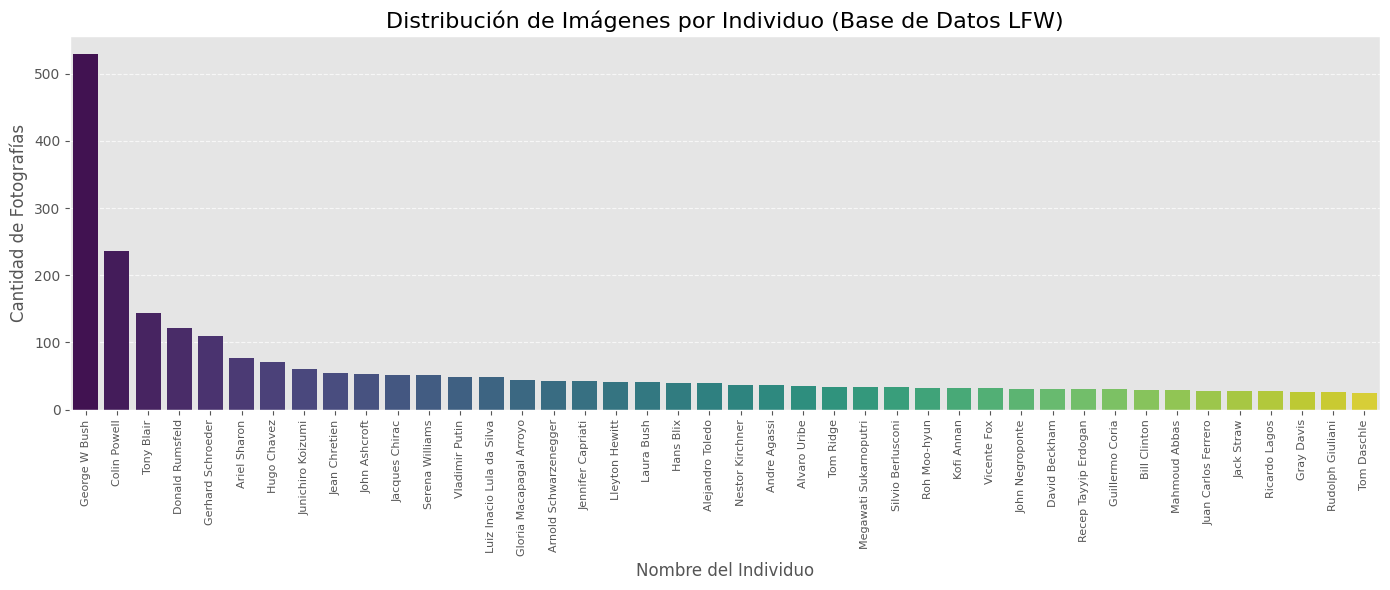

In [ ]:
# Utilice este espacio para escribir el código.
# ========================================================================================================================================================================
# 3. Distribución de imágenes por individuos
# ========================================================================================================================================================================

### a. Contamos cuantas veces aparece cada nombre de las personas en el dataset
name_tags = names_people[y]

### b. Volvemos este objeto (name_tags) una serie de Pandas
images_count = pd.Series(name_tags).value_counts()


### c. Diagrama de barras (barplot) que nos permite visualizar la distribución de los nombres de las personas en el dataset
plt.figure(figsize=(14, 6))
plt.xticks(rotation=90, fontsize=8)
sns.barplot(x = images_count.index, y = images_count.values, palette='viridis')
plt.title('Distribución de Imágenes por Individuo (Base de Datos LFW)', fontsize=16)
plt.ylabel('Cantidad de Fotografías', fontsize=12)
plt.xlabel('Nombre del Individuo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Conteo:** necesitamos contar cuántas veces aparecen las cetegorías de los nombres del dataset. Para esto usamos corchetes cuadrados para extraer las etiquetas del array de nombres.

**- Serie en pandas:** necesitamos convertir el objeto de las etiquetas (images_count) en un objeto Serie de Pandas que contenga una tabla de frecuencia hecha mediante la funciín *value_counts()*.

**- Interpretación de la gráfica:** el barplot muestra una asimetría a la derecha en la que los dos primeros nombres de 'George W Bush' y 'Colin Powell' presentan una alta frecuencia en el número de conteos. Esto puede ser problemético en un PCA, ya que los primeros componentes se verán muy influenciados por la cateegoría de 'George W Bush'.

- ¿Cuántas imágenes pertenecen a Serena Williams? Grafíquelas

El ID de Serena Williams es: 35
Se encontraron 52 fotos de Serena Williams.



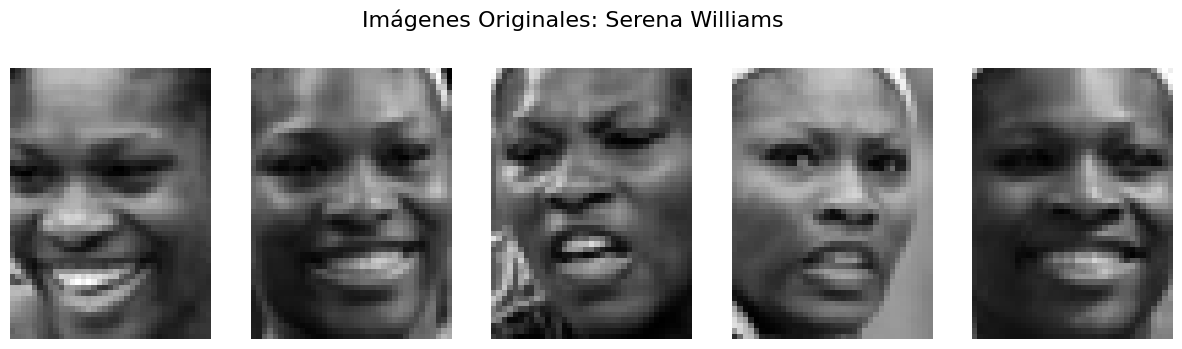

In [34]:
# Utilice este espacio para escribir el código.

# ========================================================================================================================================================================
# 4. Visualización de rostros
# ========================================================================================================================================================================================

### a. Encontrando el id para Serena Williams
serena_id = np.where(names_people == 'Serena Williams')[0][0]

print(f"El ID de Serena Williams es: {serena_id}")

### b. Filtramos las fotos donde aparece Serena Williams
serena_index = np.where(y == serena_id)[0]
print(f"Se encontraron {len(serena_index)} fotos de Serena Williams.\n")

### c Graficamos las fotos de Serena Williams
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Imágenes Originales: Serena Williams', fontsize=16)

for i, ax in enumerate(axes):
    idx_foto = serena_index[i]
    foto_plana = X[idx_foto]
    foto_rectangular = foto_plana.reshape((h, w))

    ax.imshow(foto_rectangular, cmap='gray')
    ax.axis('off')

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Encontrando el id de Serena Williams:** usamos la librería NumPy, con el comando *np.Where()*, para encontrar la etiqueta correspondiente al string de 'Serena Williams' y lo guardamos en el objeto serena_id. El resultados nos arroja que la etiqueta de Serena Williams es igual al número 35.

**- Filtrando las imágenes de Serena:** ya con el objeto serena_id filtramos esta etiqueta en el array de los nombres (y) y obtenemos el filtro para Serena y lo guardamos en el objeto serena_index.

**- Graficamos las 5 primeras fotos de Serena:** usamos el objeto serena_index dentro de un loop-for para extraer los pixeles de la imagen, lo convertimos en una matriz de dos dimensiones y graficamos la escala de grises.

### 3.  Reconociendo rostros: las eigenfaces

Las eigenfaces son un conjunto de eigenvectors utilizados en el campo de la visión por computadora, principalmente en el reconocimiento de rostros. Son el resultado de reducir la dimensión de un gran conjunto de imágenes faciales, manteniendo la información que es más relevante para diferenciar las caras.

En este apartado buscaremos encontrar el espacio de menor dimensión manteniendo la información que es más relevante para diferenciar las caras. Lo haremos en etapas:


#### 3.1. Rostro promedio.

Encuentre primero el "rostro promedio" y grafíquelo.  Para encontrar este rostro, necesita calcular el valor promedio de los pixeles. (*Tip: Si X es la matriz donde las filas representan las imágenes  y en las columnas el tono de gris de los píxeles, debería calcular el promedio para cada una de las columnas*).


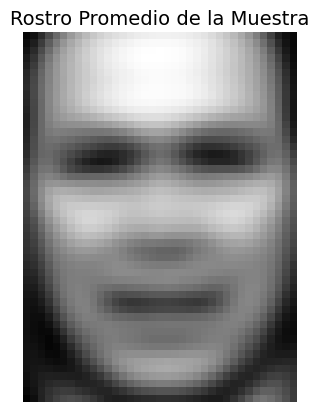

In [ ]:
# Utilice este espacio para escribir el código.

# ========================================================================================================================================================================
# 5. Calculando el valor promedio de los pixeles
# ========================================================================================================================================================================

### a. Es necesario calcular el valor promedio de cada columna (pixel) de la matriz X 
face_mean = np.mean(X, axis = 0)

### b. Con la altura (h) y el ancho (w) reconstruimos un rectángulo de 50x37 pixeles
face_mean_img = face_mean.reshape((h, w))

### c. Graficamos el rostro promedio de la muestra
plt.imshow(face_mean_img, cmap='gray')
plt.title('Rostro Promedio de la Muestra', fontsize=14)
plt.axis('off')
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Promedio:** con la función np.mean() calculamos el promedio de las columnas de la matriz X.

**- Rectángulo:** obtenemos la altura (h) y el ancho (w) para construir un rectángulo de la imagen promedio y guardamos esto en el objeto *face_mean_img*.

**- Rostro promedio:** graficamos el rostro promedio con la información calculada en las líneas anteriores.

#### 3.2. Reste el rostro promedio.

A cada una de las imágenes, reste el rostro promedio, es decir, reste la media a cada columna. Grafique las imágenes de Serena Williams luego de quitarle el rostro promedio.

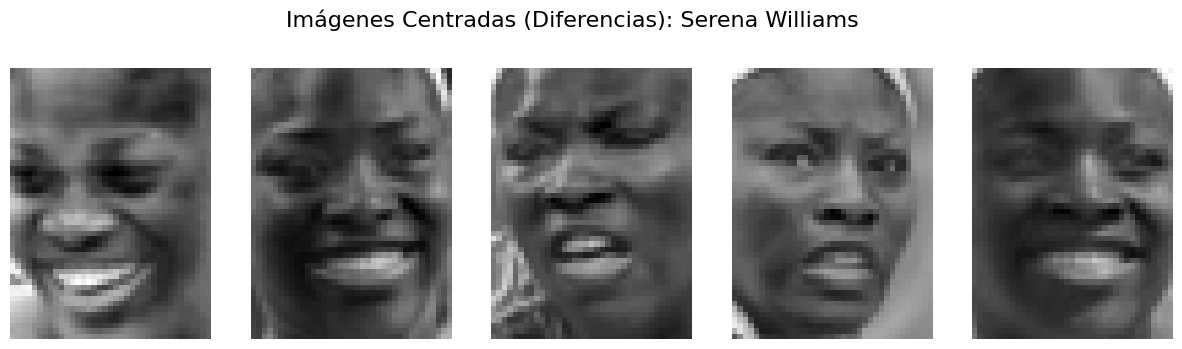

In [43]:
# Utilice este espacio para escribir el código.

# ==========================================
# 6. Resta del rostro promedio
# ==========================================

### a. Restamos el rostro promedio a la matriz de datos X
X_centrada = X - face_mean

### b. Gráficando las imágenes centradas de Serena Williams

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Imágenes Centradas (Diferencias): Serena Williams', fontsize=16)

for i, ax in enumerate(axes):
    idx_foto = serena_index[i]
    foto_centrada_plana = X_centrada[idx_foto]
    foto_centrada_rectangular = foto_centrada_plana.reshape((h, w))

    ax.imshow(foto_centrada_rectangular, cmap='gray')
    ax.axis('off')

plt.show()   

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Centrado:** para calcular la matriz centrada es necesario hacer una resta entre la matriz X (dataset) y el promedio de los rostros.


**- Gráfica de rostros:** con el objeto de la matriz centrada, se realiza una gráfica de los rostros promedio de Serena Williams a través de un loop-for.

#### 3.3. Descomposición en Valores Singulares

Aplique la Descomposición en Valores Singulares a estas nuevas imágenes y retenga solo $K=1000$ valores singulares? ¿Qué proporción de la varianza representan esto valores singulares?

In [49]:
# Utilice este espacio para escribir el código.

# ==========================================================================================================================================================
# 7.Descomposición de Valores Singulares (SVD)
# ==========================================================================================================================================================

### a. Configurando el modelo SVD con 1000 componentes (k = 1000)
K = 1000

svd_model = PCA(n_components = K, 
                svd_solver = 'randomized', 
                whiten = True, 
                random_state = 42)


### b. Entrenamos el modelo con las imágenes centradas
svd_model.fit(X_centrada)

### c. Calculando la proporción de la varianza explicada por cada componente
explained_variance_ratio = np.sum(svd_model.explained_variance_ratio_)

print(f"Proporción de la varianza total representada por {K} valores singulares: {explained_variance_ratio * 100:.2f}%")

Proporción de la varianza total representada por 1000 valores singulares: 99.89%


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Componentes del modelo y entrenamiento:** para hacer el modelo de PCA es necesario fijar 1000 componentes (K = 1000), que los valores singulares sean aleatorios y entremanos el modelo con la matriz centrada.

**- Varianza explicada:** con la función *explained_variance_ratio_* y la sumatoria de NumPy podemos calcular la proporción de la varianza explicada del modelo que es aproximadamente de 99,89%

#### 3.4. Representando los rostros en las bases

Las eigenfaces nos dice que cada rostro puede ser representado a partir de la aproximación a la matriz original por la matriz de dimensión reducida determinada en el punto anterior más el rostro promedio. Muestre que esto es posible para las imágenes de Serena Williams. Compare las imágenes reconstruidas con las originales.

In [ ]:
# Utilice este espacio para escribir el código.

# ==========================================================================================================================================================
# 8. Reconstrucción de eigenfaces
# ==========================================================================================================================================================

### a. Calculamos los pesos de cada imagen en la base de eigenfaces
images_weights = svd_model.transform(X_centrada)

### b. Reconstrucción de las imágenes utilizando los pesos y la base de eigenfaces
X_reconstruida_centrada = svd_model.inverse_transform(images_weights)

### c. Sumamos el rostro promedio a las imágenes reconstruidas para obtener las imágenes finales
X_reconstruida = X_reconstruida_centrada + face_mean

### d. Graficamos las imágenes reconstruidas de Serena Williams
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Comparación: Imágenes Originales vs. Reconstruidas (Serena Williams)', fontsize=16)

for i in range(5):
    idx_foto = serena_index[i]

    foto_original = X[idx_foto].reshape((h, w))
    axes[0, i].imshow(foto_original, cmap='gray')
    axes[0, i].set_title(f"Original {i+1}")
    axes[0, i].axis('off')

    foto_reconstruida = X_reconstruida[idx_foto].reshape((h, w))
    axes[1, i].imshow(foto_reconstruida, cmap='gray')
    axes[1, i].set_title(f"Reconstruida {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Pesos de los eigenfaces:** empezamos calculando el peso de los eigenfaces a partir de la matriz centrada y le aplicamos una transformación inversa.

**- Imágenes Finales:** para obtener las imágenes finales es necesario sumar la matriz reconstruida con el promedio de los rostros.

**- Gráfica de imágenes:** ahora podemos hacer la comparación de las imágenes de Serena entre las originales y las reconstruidas. Ambas son similares y no hay grandes diferencias entre ellas.

### 4. Uniendo Aprendizaje No Supervisado y Supervisado

Dado que cada rostro puede ser representado por las eigenfaces, y la relación que existe entre componentes principales y la SVD, esto sugiere que los componentes principales aquí determinados pueden servir de insumo para un algoritmo de clasificación de aprendizaje supervisado. En este sección del taller haremos esto.

Para ello construiremos un modelo de clasificación logístico para predecir si la imagen pertenece a `George W Bush`  (el individuo con más imágenes en la base)  o no.

#### 4.1. Identificando a `George W Bush`

Cree una variable binaria que tome el valor 1 si la imagen pertenece a `George W Bush` y 0 en caso contrario.

In [59]:
# Utilice este espacio para escribir el código.

# ==========================================================================================================================================================
# 9. Variable binaria para 'George W. Bush' (1 para George W. Bush y 0 de lo contrario)      
# ==========================================================================================================================================================

### a. Buscamos el ID de George W. Bush en el array de nombres de personas
bush_id = np.where(names_people == 'George W Bush')[0][0]

print(f'El ID de George W. Bush es: {bush_id}')

### b. Creamos la variable binaria para Bush, donde 1 indica que la foto es de Bush y 0 indica lo contrario
y_bush = (y == bush_id).astype(int)

### c. ¿Cómo es el balance de la variable entre 1 y cero?
total_bush = np.sum(y_bush)

total_otros = len(y_bush) - total_bush

### d. Total de unos y ceros
print(f"Imágenes de George W. Bush (1): {total_bush}")
print(f"Imágenes de otras personas (0): {total_otros}")




El ID de George W. Bush es: 9
Imágenes de George W. Bush (1): 530
Imágenes de otras personas (0): 2058


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Buscando el ID de 'George W Bush':** para empezar, es obligatorio buscar el ID de Bush. Esto lo hacemos con el mismo código con el que encontramos el ID de Serena Williams.

**- Variable dicotómica:** la variable binaria la construímos a partir del *bush_id*, en donde los strings iguales a 'George W. Bush' son iguales a 1 y los diferentes van a tener la categoría de 0.

**- Balance de categorías:** calculamos el número absoluto de las categorías de la variable dicotómica y llegamos al resultado de tener 530 unos y 2058 ceros.


#### 4.2. Bases de Entrenamiento y Prueba.

Divida la base utilizada anteriormente en dos: 80% de la base de imágenes asígnelas a la base de entrenamiento y el 20% restante a la de prueba, utilice un `random_state=10101`.

In [64]:
# Utilice este espacio para escribir el código.

# ==========================================================================================================================================================
# 10. Partición de los datos de entrenamiento y prueba
# ==========================================================================================================================================================

### a. Dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%) utilizando la función train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_bush, 
    test_size = 0.20, 
    random_state = 10101
)

### b. Resumen de la cantidad de imágenes en cada conjunto y el número de variables predictoras

print(f"Entrenamiento (80%): {X_train.shape[0]} imágenes")
print(f"Prueba (20%): {X_test.shape[0]} imágenes")
print(f"Variables predictoras (K): {X_train.shape[1]} componentes SVD")

Entrenamiento (80%): 2070 imágenes
Prueba (20%): 518 imágenes
Variables predictoras (K): 1850 componentes SVD


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- División en train y test:** para dividir los datos en los conjuntos de entrenamiento y prueba, se usa la función de train_test_split para partir los datos de la matriz X y usamos una aleatorización de 10101.

**- Resultado de la división:** la división queda con 2070 imágenes de entrenamiento y 518 de prueba.




#### 4.3. Descomposición en Valores Singulares

Para la base de entrenamiento y de prueba, realice la descomposición en valores singulares (Recuerde recentrar las matrices para que tenga media 0).

In [65]:
# Utilice este espacio para escribir el código.

# ==========================================================================================================================================================
# 11. Re-centrado y SVD
# ==========================================================================================================================================================

### a. Calcular el rostro promedio con el conjunto de entrenamiento
face_mean_train = np.mean(X_train, axis = 0)

### b. Centrando las matrices de entrenamiento y prueba restando el rostro promedio del conjunto de entrenamiento 
X_train_center = X_train - face_mean_train 
X_test_center = X_test - face_mean_train 

### c. Configuramos el modelo SVD con 1000 componentes (k = 1000)
svd_clasificacion = PCA(n_components = 1000, 
                        svd_solver = 'randomized', 
                        whiten = True, 
                        random_state = 42)

### d. Se entrena el modelo SVD con el conjunto de entrenamiento centrado
svd_clasificacion.fit(X_train_center)

### e. Transformamos los pixeles centrados a Eigenfaces
X_train_pca = svd_clasificacion.transform(X_train_center)
X_test_pca = svd_clasificacion.transform(X_test_center)

print(f"Dimensiones de Entrenamiento listas para el modelo: {X_train_pca.shape}")
print(f"Dimensiones de Prueba listas para el modelo: {X_test_pca.shape}")

Dimensiones de Entrenamiento listas para el modelo: (2070, 1000)
Dimensiones de Prueba listas para el modelo: (518, 1000)


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

Calculamos un nuevo rostro promedio con el 80% de entrenamiento y ese nuevo rostro promedio se obtuvo restando la m,atriz de entrenamiento y prueba. Después, ajustamos el modelo SVD sobre la matriz X centrada. Finalmente, tenemos dos matrices de eigenfaces que serán las variables independientes. 

#### 4.4. Estimación de modelo de aprendizaje supervisado


Utilizando $k=1000$ valores singulares, construya los 1000 primeros componentes principales y úselos como predictores en su modelo logístico. Utilice como métrica de performance el porcentaje de imágenes de `George W Bush` clasificadas correctamente.

Para estimar su modelo logístico Utilice el `solver='sag`,`random_state=10101` y `max_iter=1000`. Como se muestra a continuación:



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Modelo_Logistico = LogisticRegression(solver='sag',random_state=10101,max_iter=1000)

# Utilice este espacio para escribir el código restante.


# ==============================================================================================================================================
# 12. Modelo de Regresión Logística
# ==============================================================================================================================================

### b. Entrenamos el modelo de Regresión Logística con los datos de entrenamiento transformados por SVD
Modelo_Logistico.fit(X_train_pca, y_train)

### c. Realizamos predicciones sobre el conjunto de prueba
y_pred = Modelo_Logistico.predict(X_test_pca)

### d. Calculamos la matriz de confusión para extraer los verdaderos positivos
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

### Calculamos el porcentaje de imágenes de George W. Bush identificadas correctamente (verdaderos positivos)
porcentaje_bush_correcto = (tp / (tp + fn)) * 100
exactitud_global = accuracy_score(y_test, y_pred) * 100

### Métricas globales
print(f"Exactitud Global (Accuracy): {exactitud_global:.2f}%")
print(f"Imágenes de G.W. Bush identificadas correctamente: {porcentaje_bush_correcto:.2f}%")
print(classification_report(y_test, y_pred, target_names=['Otros', 'George W. Bush']))

Exactitud Global (Accuracy): 84.36%
Imágenes de G.W. Bush identificadas correctamente: 62.50%
                precision    recall  f1-score   support

         Otros       0.90      0.90      0.90       406
George W. Bush       0.64      0.62      0.63       112

      accuracy                           0.84       518
     macro avg       0.77      0.76      0.77       518
  weighted avg       0.84      0.84      0.84       518



(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**- Regresión logística:** calculamos el modelo de regresión logística con la matriz X centrada de entrenamiento y el y_test.

**- Predicción:** hacemos las predicciones sobre el conjunto de datos de prueba (X_test_pca)

**- Métricas básicas:** calculamos las tasas de verdaderos posotivos, verdaderos negativos, falsos negativos y falsos positivos.

**- Interpretación para Bush:** la sensibilidad indica que el modelo identifica correctamente el 62.5% de los rostros reales de Bush y la precisión muestra que todas las imágenes que fueron identificadas como Bush. Es un modelo aceptable que se ve influenciado por el desbalance de clases entre Bush (1) y el resto de categorías (0).   

#### 4.5. Mejorando el Ajuste

Trate ahora el número de valores singulares como un hiper-parámetro a encontrar. Emplee validación cruzada con 5 o 10 folds (dependiendo de su poder computacional) para encontrar el número óptimo de valores singulares. Con este modelo, evalúe el porcentaje de imágenes de `George W Bush` clasificadas correctamente en su muestra de prueba. Compare y discuta esta forma de elegir el número de variables con aquella utilizada en  4.4. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [ ]:
# Utilice este espacio para escribir el código.

# ======================================================================================================================================================================================
# 13. Validación Cruzada (VC)
# ======================================================================================================================================================================================


#### Funciones necesarias para la VC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

#### a. Configuramos un pipeline que incluye el modelo SVD y el modelo de Regresión Logística
pipeline = Pipeline([
    ('pca', PCA(svd_solver='randomized', whiten=True, random_state=42)),
    ('logreg', LogisticRegression(solver='sag', random_state=10101, max_iter=1000))
])


#### b. Definimos el rango de valores de K (número de componentes singulares) que queremos evaluar en la validación cruzada
parametros_grid = {
    'pca__n_components': [50, 150, 300, 500, 750, 1000]
}


#### c. Configuramos la VC con GridSearchCV para encontrar el número óptimo de componentes singulares (K) que maximice la exactitud del modelo
grid_search = GridSearchCV(
    pipeline, 
    parametros_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1 # Muestra el progreso en pantalla
)

#### d. Ejecutamos la VC con el conjunto de entrenamiento centrado
grid_search.fit(X_train_center, y_train)

#### e. Extraemos el número óptimo de componentes singulares (K) encontrado por la VC y el mejor modelo
mejor_k = grid_search.best_params_['pca__n_components']
mejor_modelo = grid_search.best_estimator_

#### f. Realizamos predicciones con el mejor modelo encontrado sobre el conjunto de prueba centrado
y_pred_optimo = mejor_modelo.predict(X_test_center)


#### g. Calculamos métricas para el modelo optimizado
print(f"El número ÓPTIMO de componentes singulares encontrado fue: K = {mejor_k}")


#### h. Realizamos predicciones con el mejor modelo encontrado sobre el conjunto de prueba centrado
y_pred_optimo = mejor_modelo.predict(X_test_center)

#### i. Calculamos métricas para el modelo optimizado
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimo).ravel()
porcentaje_bush_optimo = (tp / (tp + fn)) * 100
exactitud_global_optima = accuracy_score(y_test, y_pred_optimo) * 100

#### j. Resultados del modelo optimizado
print("-" * 55)
print("=== RESULTADOS DEL MODELO OPTIMIZADO ===")
print(f"Exactitud Global (Accuracy): {exactitud_global_optima:.2f}%")
print(f"Imágenes de G.W. Bush identificadas correctamente: {porcentaje_bush_optimo:.2f}%")
print("-" * 55)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
El número ÓPTIMO de componentes singulares encontrado fue: K = 150
-------------------------------------------------------
=== RESULTADOS DEL MODELO OPTIMIZADO ===
Exactitud Global (Accuracy): 90.73%
Imágenes de G.W. Bush identificadas correctamente: 70.54%
-------------------------------------------------------


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).